In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings("ignore")

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_curve, auc
)

In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [5]:
df = pd.read_csv("household_power_consumption (1).txt", sep=";", na_values=["?"], low_memory=False)
print(f"Raw shape: {df.shape}")

Raw shape: (946394, 9)


In [6]:
df["Datetime"] = pd.to_datetime(df["Date"] + " " + df["Time"],
                                format="%d/%m/%Y %H:%M:%S", errors="coerce")
df.drop(columns=["Date", "Time"], inplace=True)

In [7]:
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df.dropna(subset=["Datetime"], inplace=True)

In [8]:
np.random.seed(42)
df["Hour"] = df["Datetime"].dt.hour
df["Month"] = df["Datetime"].dt.month

In [9]:
df["Temperature"] = (
    20 + 8 * np.sin(2 * np.pi * (df["Hour"] - 6) / 24)
    + 4 * np.sin(2 * np.pi * df["Month"] / 12)
    + np.random.normal(0, 2, len(df))
)

In [10]:
df["Humidity"] = (
    55 - 8 * np.sin(2 * np.pi * df["Hour"] / 24)
    + np.random.normal(0, 6, len(df))
).clip(20, 95)


In [11]:
df["Sub_Metering_Total"] = (
    df["Sub_metering_1"] + df["Sub_metering_2"] + df["Sub_metering_3"]
)


In [12]:
df["Light_Availability"] = (df["Hour"].between(7, 19)).astype(int)
df["Voltage"]          = pd.to_numeric(df["Voltage"], errors="coerce").fillna(230)
df["Global_Intensity"] = pd.to_numeric(df["Global_intensity"], errors="coerce").fillna(0)

In [13]:
df["Global_active_power"] = pd.to_numeric(df["Global_active_power"], errors="coerce")
df["Global_active_power"].fillna(df["Global_active_power"].median(), inplace=True)

In [14]:
p40 = df["Global_active_power"].quantile(0.40)
p60 = df["Global_active_power"].quantile(0.60)
median = df["Global_active_power"].median()


In [15]:
df["Power_Status"] = (df["Global_active_power"] > median).astype(int)


In [16]:
band = df["Global_active_power"].between(p40, p60)
flip_idx = df[band].sample(frac=0.55, random_state=99).index
df.loc[flip_idx, "Power_Status"] = 1 - df.loc[flip_idx, "Power_Status"]

In [17]:
print(f"Median threshold : {median:.4f} kW")
print(f"Class distribution:\n{df['Power_Status'].value_counts()}")

Median threshold : 0.5100 kW
Class distribution:
Power_Status
1    473734
0    472660
Name: count, dtype: int64


In [18]:
FEATURES = ["Temperature", "Humidity", "Hour",
            "Voltage", "Global_Intensity",
            "Sub_Metering_Total", "Light_Availability"]


In [19]:
X = df[FEATURES]
y = df["Power_Status"]

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [21]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

In [22]:
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
print("Scaler saved → scaler.pkl")

Scaler saved → scaler.pkl


In [23]:
tf.random.set_seed(42)

In [24]:
model = Sequential([
    Dense(16, activation="relu", input_shape=(7,)),
    Dropout(0.2),
    Dense(8,  activation="relu"),
    Dense(1,  activation="sigmoid")
])

In [25]:
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 273 (1.07 KB)

 Trainable params: 273 (1.07 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
early_stop = EarlyStopping(monitor="val_loss", patience=8,
                           restore_best_weights=True, verbose=1)

In [27]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=80,
    batch_size=1024,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/80
592/592 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8208 - loss: 0.3801 - val_accuracy: 0.8947 - val_loss: 0.2407
Epoch 2/80
592/592 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8941 - loss: 0.2438 - val_accuracy: 0.8935 - val_loss: 0.2184
Epoch 3/80
592/592 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8936 - loss: 0.2177 - val_accuracy: 0.8933 - val_loss: 0.1967
Epoch 4/80
592/592 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8939 - loss: 0.2015 - val_accuracy: 0.8935 - val_loss: 0.1856
Epoch 5/80
592/592 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8943 - loss: 0.1913 - val_accuracy: 0.8934 - val_loss: 0.1772
Epoch 6/80
592/592 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8943 - loss: 0.1814 - val_accuracy: 0.8940 - val_loss: 0.1703
Epoch 7/80
592/592 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8953 - loss: 0.1746 - val_accuracy: 0.8946 - val_loss: 0.1663
Epoch 8/80
592/592 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8961 - loss: 0.1706 - val_accuracy: 0.

In [28]:
model.save("model.h5")
print("Model saved → model.h5")

Model saved → model.h5


In [29]:
y_prob = model.predict(X_test).flatten()
y_pred = (y_prob >= 0.5).astype(int)

5915/5915 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step


In [30]:
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

In [31]:
print("\n========================================")
print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1 Score  : {f1:.4f}")
print("========================================")
print(classification_report(y_test, y_pred, target_names=["LOW (OFF)", "HIGH (ON)"]))


  Accuracy  : 0.8997
  Precision : 0.9936
  Recall    : 0.8049
  F1 Score  : 0.8893
              precision    recall  f1-score   support

   LOW (OFF)       0.84      0.99      0.91     94532
   HIGH (ON)       0.99      0.80      0.89     94747

    accuracy                           0.90    189279
   macro avg       0.91      0.90      0.90    189279
weighted avg       0.91      0.90      0.90    189279



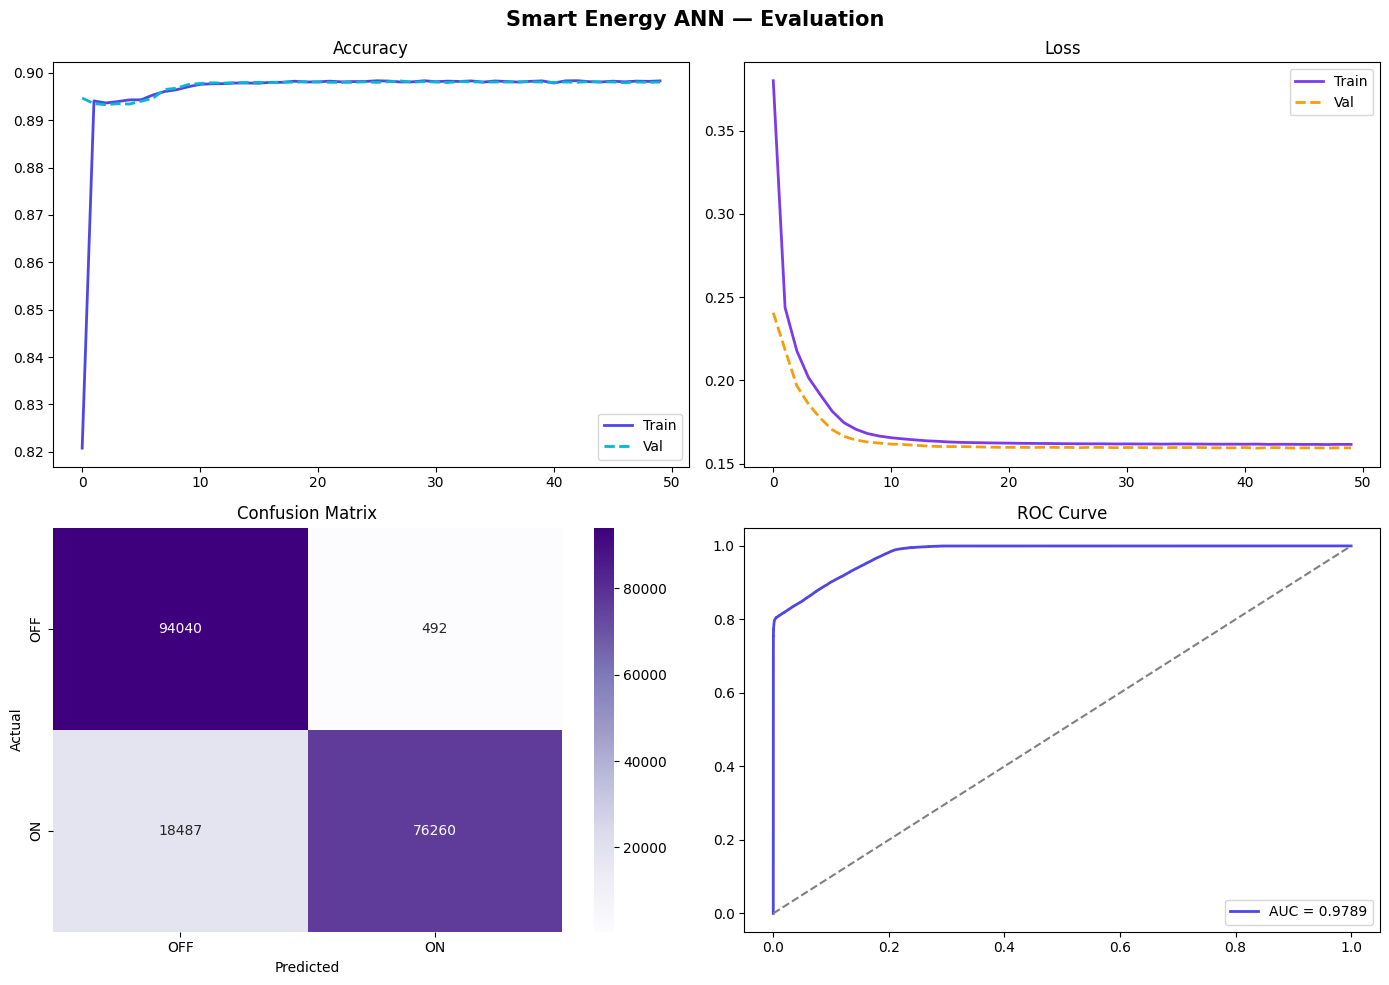

Plots saved → evaluation_plots.png


In [38]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Smart Energy ANN — Evaluation", fontsize=15, fontweight="bold")

# Accuracy curve
axes[0,0].plot(history.history["accuracy"],     label="Train", color="#4f46e5", lw=2)
axes[0,0].plot(history.history["val_accuracy"], label="Val",   color="#06b6d4", lw=2, ls="--")
axes[0,0].set_title("Accuracy"); axes[0,0].legend()

# Loss curve
axes[0,1].plot(history.history["loss"],     label="Train", color="#7c3aed", lw=2)
axes[0,1].plot(history.history["val_loss"], label="Val",   color="#f59e0b", lw=2, ls="--")
axes[0,1].set_title("Loss"); axes[0,1].legend()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples", ax=axes[1,0],
            xticklabels=["OFF","ON"], yticklabels=["OFF","ON"])
axes[1,0].set_title("Confusion Matrix")
axes[1,0].set_xlabel("Predicted"); axes[1,0].set_ylabel("Actual")
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
axes[1,1].plot(fpr, tpr, color="#4f46e5", lw=2, label=f"AUC = {roc_auc:.4f}")
axes[1,1].plot([0,1],[0,1], color="gray", ls="--")
axes[1,1].set_title("ROC Curve"); axes[1,1].legend()
plt.tight_layout()
plt.savefig("evaluation_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plots saved → evaluation_plots.png")